In [26]:
import pylab as plt
import numpy as np
import seaborn as sns; sns.set()
import pandas as pd
import keras
from keras.datasets import mnist
from keras.models import Sequential, Model
from keras.layers import Dense, Input
from keras.optimizers import Adam

#  y_test) = mnist.load_data()
# x_train = x_train.reshape(60000, 784) / 255
# x_test = x_test.reshape(10000, 784) / 255
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"


cleaned_data_path = "../data/engcensus_cleaned_scaled.parquet"
#load the cleaned data
df_scaled = pd.read_parquet(cleaned_data_path)
df_scaled

# #shape the data and test train split
# df_scaled = df_scaled.sample(frac=1).reset_index(drop=True)
df_scaled = df_scaled.drop(columns=["OA"])

#to numpy
df_scaled = df_scaled.to_numpy()
from sklearn.model_selection import train_test_split
x_train, x_test = train_test_split(df_scaled, test_size=0.2, random_state=42)
print(x_train.shape, x_test.shape)



(151104, 429) (37776, 429)


In [57]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


All_census = pd.read_parquet(cleaned_data_path)

# Filter columns with 'ts' in their names.
ts_columns = [col for col in All_census.columns if 'ts' in col]
ts_data = All_census[ts_columns]

# # Standardize the data.
scaler = StandardScaler()
ts_data_std = scaler.fit_transform(ts_data)

# Apply PCA to account for 80% of the variance.
pca = PCA(n_components=0.8)  # Adjusted to select components for 80% variance.
pca.fit(ts_data)

# The explained variance ratio indicates the importance of each principal component.
explained_variance_ratio = pca.explained_variance_ratio_

# Number of components chosen.
num_components_chosen = pca.n_components_

# Components_ gives the loadings of each variable on the principal components.
loadings = pca.components_

# Calculate the overall importance of each variable within the chosen components.
# This is done by summing the squares of the loadings across the chosen components for each variable.
overall_importance = np.sum(loadings**2, axis=0)

# Identify the indices of the most important variables based on overall importance within the chosen components.
important_indices = np.argsort(overall_importance)[::-1][:min(200, num_components_chosen)]

# Extract the names of the most important variables.
important_variables = np.array(ts_columns)[important_indices]

In [58]:
ts_data_std

array([[ 0.19461812, -0.19461812,  0.90936527, ...,  2.14412482,
        -0.42273524, -0.76277612],
       [ 0.19461812, -0.19461812,  0.99144582, ...,  1.44491581,
         0.31524077, -0.76277612],
       [ 0.19461812, -0.19461812, -0.06813953, ...,  1.10123681,
        -2.03830436, -0.18227942],
       ...,
       [ 0.19461812, -0.19461812,  0.13333093, ...,  0.89976981,
         0.19556899, -0.24677905],
       [ 0.19461812, -0.19461812,  0.77505163, ...,  2.51150583,
        -0.44268054, -0.24677905],
       [ 0.19461812, -0.19461812, -0.3367668 , ..., -0.22607521,
         0.55458435, -0.76277612]])

In [56]:
pca.n_components_

np.int64(14)

In [47]:
n_comp=2

In [1]:
def compute_errors(original, reconstructed):
    """Compute RMSE and MAE between original and reconstructed data."""
    error = original - reconstructed
    #print any nans series
    if error.isna().any().any():
        print("Nans in error")
        print(error)
    return np.sqrt(np.mean(error ** 2)/original.mean(dim=1)), np.mean(np.abs(error))

reconstructed_pca = pd.read_csv(f"../data/PCA/{n_comp}_components.csv",index_col=0)
pca_rmse, mae = compute_errors(df_scaled, reconstructed_pca)
print(f"PCA RMSE: {pca_rmse}")

NameError: name 'pd' is not defined

In [49]:
mu = x_train.mean(axis=0)
U,s,V = np.linalg.svd(x_train - mu, full_matrices=False)
Zpca = np.dot(x_train - mu, V.transpose())

Rpca = np.dot(Zpca[:,:n_comp], V[:n_comp,:]) + mu    # reconstruction
err = np.sum((x_train-Rpca)**2)/Rpca.shape[0]/Rpca.shape[1]
print(f'PCA reconstruction error with {n_comp} PCs: ' + str(round(err,10)))

# Explained variance
explained_var = (s[:n_comp]**2).sum() / (s**2).sum()
print(f'Explained variance with {n_comp} PCs: {round(explained_var * 100, 2)}%')

PCA reconstruction error with 2 PCs: 0.0035743797
Explained variance with 2 PCs: 42.95%


In [30]:
np.sqrt( 6.80111e-05)

np.float64(0.008246884260131216)

In [33]:
m = Sequential([
    Input(shape=(429,)),  # 👈 This is a layer now, not a tensor
    Dense(512, activation='elu'),
    Dense(256, activation='elu'),
    Dense(n_comp, activation='linear', name="bottleneck"),
    Dense(256, activation='elu'),
    Dense(512, activation='elu'),
    Dense(429, activation='sigmoid')
])
m.compile(loss='mean_squared_error', optimizer = Adam())
history = m.fit(x_train, x_train, batch_size=128, epochs=2, verbose=1, 
                validation_data=(x_test, x_test))

# Ensure model is built (usually it is after fit, but just in case)
if not m.built:
    m.build(input_shape=(None, 429))

encoder = Model(m.input, m.get_layer('bottleneck').output)
Zenc = encoder.predict(x_train)  # bottleneck representation
Renc = m.predict(x_train)        # reconstruction

Epoch 1/2
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 0.0063 - val_loss: 5.2916e-04
Epoch 2/2
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 4.6902e-04 - val_loss: 3.5433e-04


AttributeError: The layer sequential_5 has never been called and thus has no defined input.

In [38]:
from keras.layers import Input, Dense
from keras.models import Model
from keras.optimizers import Adam

# Functional API version
inp = Input(shape=(429,))
x = Dense(512, activation='elu')(inp)
x = Dense(256, activation='elu')(x)
encoded = Dense(n_comp, activation='linear', name='bottleneck')(x)
x = Dense(256, activation='elu')(encoded)
x = Dense(512, activation='elu')(x)
out = Dense(429, activation='sigmoid')(x)

autoencoder = Model(inputs=inp, outputs=out)
autoencoder.compile(loss='mean_squared_error', optimizer=Adam(8e-4))

# Train
history = autoencoder.fit(x_train, x_train, batch_size=128, epochs=50, verbose=1,
                          validation_data=(x_test, x_test))

# Encoder model
encoder = Model(inputs=inp, outputs=encoded)
Zenc = encoder.predict(x_train)
Renc = autoencoder.predict(x_train)


Epoch 1/50
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 0.0075 - val_loss: 5.8597e-04
Epoch 2/50
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5.1798e-04 - val_loss: 3.9291e-04
Epoch 3/50
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 3.5974e-04 - val_loss: 2.9852e-04
Epoch 4/50
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 2.8848e-04 - val_loss: 2.5303e-04
Epoch 5/50
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 2.4249e-04 - val_loss: 2.1639e-04
Epoch 6/50
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 2.0813e-04 - val_loss: 1.9838e-04
Epoch 7/50
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 1.8318e-04 - val_loss: 1.7090e-04
Epoch 8/50
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 1.6664e-04 - val_loss: 1.6632e-04
Epoch 9/50
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 1.5088e-04 - val_loss: 1.4770e-04
Epoch 10/50
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 1.3934e-04 - val_loss: 1.3390e-04
Epoch 11/50
1181/1181 ━━━━━━━

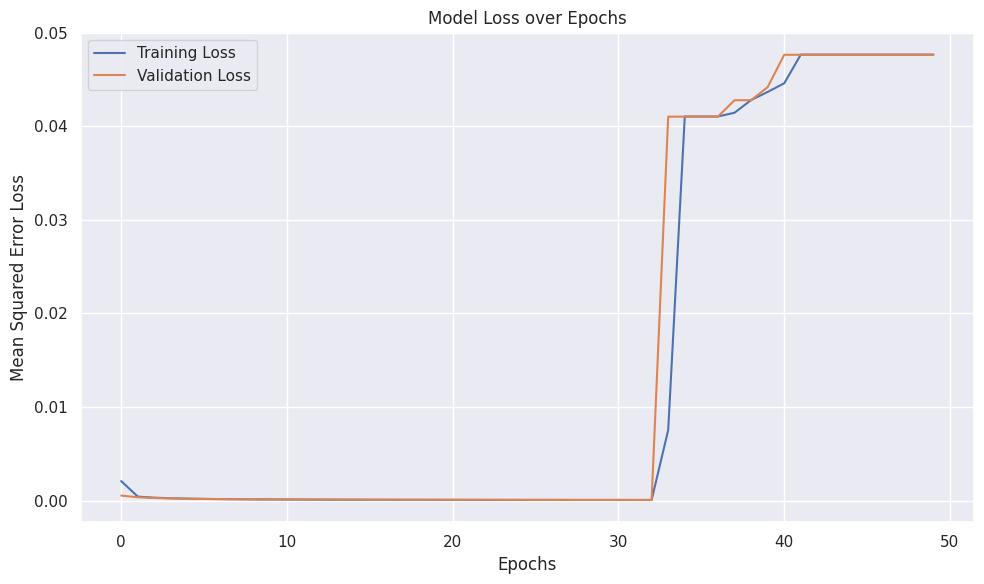

In [36]:
import matplotlib.pyplot as plt

# Plot loss vs. epochs
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [4]:
%pip install "tensorflow==2.14.0"


ERROR: Could not find a version that satisfies the requirement tensorflow==2.14.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0)
ERROR: No matching distribution found for tensorflow==2.14.0
Note: you may need to restart the kernel to use updated packages.
